--- 財務比率計算結果 ---
                流動比率  負債權益比(倒數)       ROE
Company                                  
台積電 (2330)  2.142857   3.111111  0.357143
聯發科 (2454)  2.000000   2.500000  0.240000
鴻海 (2317)   1.200000   1.000000  0.100000
地雷科 (9999)  0.500000   0.250000 -0.500000


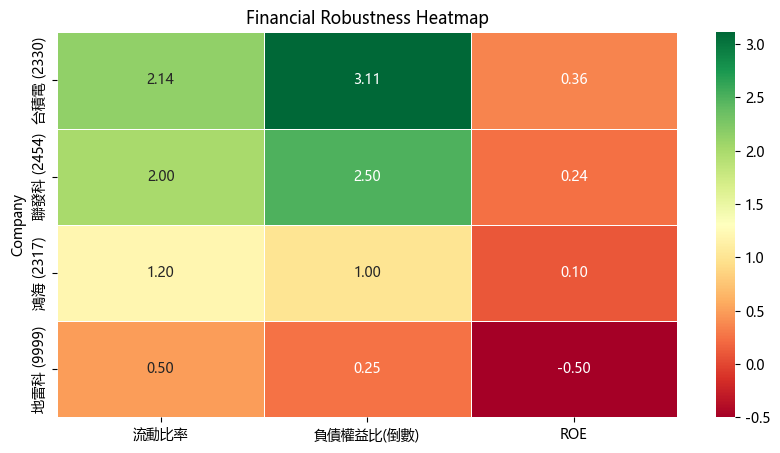

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 設定中文字體，解決中文顯示問題
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']  # 設定字體
plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題

# 1. 建立模擬財報數據 (單位：億元)
data = {
    'Company': ['台積電 (2330)', '聯發科 (2454)', '鴻海 (2317)', '地雷科 (9999)'],
    
    # 資產負債表項目
    'Current_Assets': [15000, 6000, 30000, 50],   # 流動資產 (現金、存貨)
    'Current_Liab':   [7000,  3000, 25000, 100],  # 流動負債 (一年內要還的錢)
    'Total_Debt':     [9000,  2000, 15000, 400],  # 總欠款
    'Total_Equity':   [28000, 5000, 15000, 100],  # 股東出的錢
    
    # 損益表項目
    'Net_Income':     [10000, 1200, 1500, -50]    # 稅後淨利 (賺多少)
}

df_fund = pd.DataFrame(data)

# 2. 計算三大財務指標 (Financial Ratios)
# A. 流動比率 (越高越好)
df_fund['流動比率'] = df_fund['Current_Assets'] / df_fund['Current_Liab']

# B. 負債權益比 (越低越穩，但我們為了熱力圖顏色統一，這裡顯示原始數值)
#    因負債權益比是愈小愈好，為使熱力圖顏色一致，這裡改為取其倒數
df_fund['負債權益比(倒數)'] = 1/(df_fund['Total_Debt'] / df_fund['Total_Equity'])

# C. ROE (越高越好)
df_fund['ROE'] = df_fund['Net_Income'] / df_fund['Total_Equity']

# 設定公司名稱為索引，方便畫圖
df_fund.set_index('Company', inplace=True)

# 只選出這三個指標來畫圖
df_ratios = df_fund[['流動比率', '負債權益比(倒數)', 'ROE']]

print("--- 財務比率計算結果 ---")
print(df_ratios)

# 3. 畫出財務體質熱力圖 (Heatmap)
plt.figure(figsize=(10, 5))

# 這裡我們要用一點技巧：
# ROE 和 Current Ratio 是 "越大越好" (顏色越深越好)
# Debt Ratio 是 "越小越好"，所以解讀時要小心，或者我們反向處理。
# 為了簡單，我們先直接畫，然後用人腦判讀。

sns.heatmap(df_ratios, annot=True, fmt=".2f", cmap="RdYlGn", linewidths=.5)
# cmap="RdYlGn" 代表 Red-Yellow-Green (紅-黃-綠)，綠色通常代表數值大

plt.title('Financial Robustness Heatmap')
plt.savefig('financial_health.png')